

---

### 🔍 What is the Convolution Operation?

In deep learning, especially in **image processing**, the **convolution operation** is a mathematical process used by **Convolutional Neural Networks (CNNs)** to **detect features** like edges, corners, or textures in images.

It works by sliding a small grid (called a **filter** or **kernel**) over the image. At each position, it multiplies the filter values with the corresponding pixel values and adds them up. This gives one number in a new grid called the **feature map**.

👉 **Problem with Convolution Operation**:
1. **Image gets smaller (shrinks)**:  
   Each time you apply convolution, the output image becomes smaller than the input. For example, a 5×5 image with a 3×3 filter becomes 3×3. After many layers, the image may become too small to be useful.

2. **Information loss at edges**:  
   The pixels at the edges of the image are used less often than the center pixels. This means the network may not learn good features from the edges.

3. **Fixed movement**:  
   By default, the filter moves one pixel at a time. Sometimes we want it to move faster (to reduce size quickly) or slower (to capture more detail).

---

### ✅ What is Padding?

**Padding** means adding extra rows and columns of zeros (or other values) **around the border** of the input image.

🔹 **Why use padding?**
- To **keep the size of the output the same** as the input (called *same padding*).
- To help **preserve edge information** so the network can learn from all parts of the image.

🔸 Example:  
If you have a 5×5 image and add 1 layer of zeros around it, it becomes 7×7. Then, when you apply a 3×3 filter, the output can still be 5×5.

---

### ➡️ What are Strides?

**Stride** is the number of pixels the filter **moves** each time it slides over the image.

🔹 **Small stride (e.g., 1)**:
- The filter moves one pixel at a time.
- Gives a **larger output** and more detail.
- Takes more time and memory.

🔹 **Large stride (e.g., 2)**:
- The filter jumps 2 pixels each time.
- Gives a **smaller output** faster.
- Useful when you want to reduce image size quickly.

🔸 Example:  
With a stride of 2, the filter skips every other position, so the feature map becomes smaller more quickly.

---

### ✅ Summary

| Term      | Meaning | Why It Helps |
|---------|--------|-------------|
| **Convolution** | Sliding a filter over an image to detect features | Finds patterns like edges |
| **Padding** | Adding zeros around the image | Keeps size the same and saves edge info |
| **Stride** | How far the filter moves each step | Controls output size and speed |

---



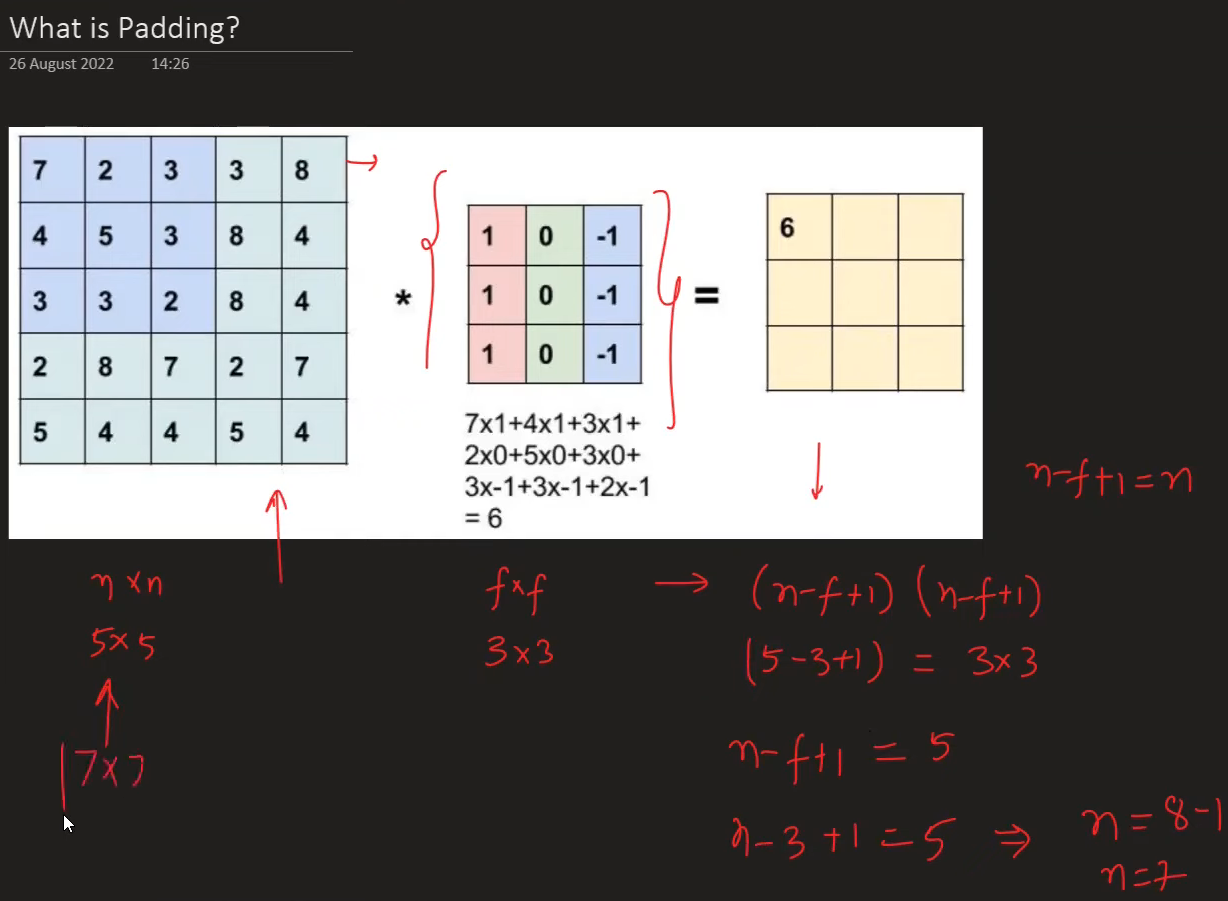

#Preserving the input size

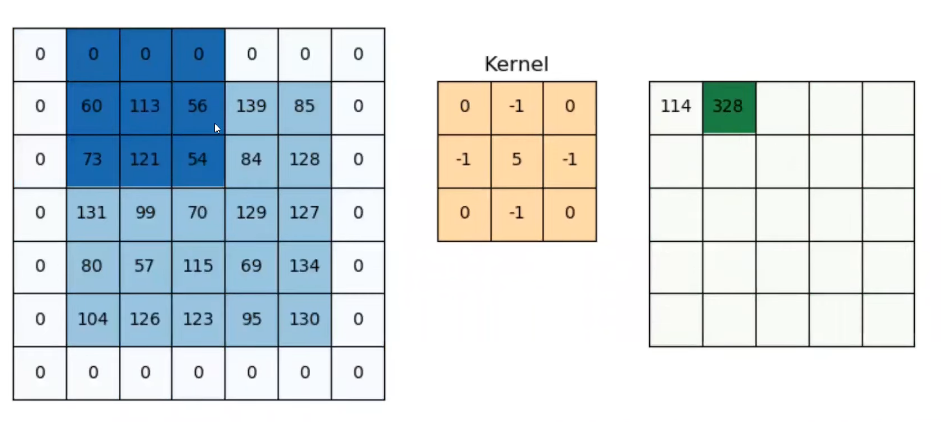

#by applying the padding layers or zero padding which eventually help to presever the input resoultion



---

### 🌟 1. **Intuition Behind Convolution**

Imagine you have a photo, and you want to find **edges** (like the outline of a cat or a tree). You don’t check every pixel one by one — instead, you use a small "magnifying glass" (called a **filter** or **kernel**) that slides over the image.

At each position, it checks:  
> "Are the pixels under me changing a lot from left to right? Or top to bottom?"

If yes → that’s likely an **edge**!

🔹 **Example filter for vertical edges**:
```
[ -1  0  1 ]
[ -1  0  1 ]
[ -1  0  1 ]
```
This filter gives:
- High value → if left side is dark, right side is bright.
- Low (or negative) value → opposite.
- Zero → if no change.

So, **convolution helps find patterns** like edges, blur, or corners by combining local pixel values with a small pattern (the filter).

---

### ➕ 2. **Maths of Convolution (Simple Example)**

Let’s say we have a tiny **4×4 image** and a **2×2 filter**:

**Input Image (I):**
```
[ 1  2  3  4 ]
[ 5  6  7  8 ]
[ 9 10 11 12 ]
[13 14 15 16 ]
```

**Filter (K):**
```
[ 1  0 ]
[ 0 -1 ]
```

We slide the filter over the image, multiply overlapping values, and add them.

#### Step 1: Top-left position
Overlap:
```
Image: [1 2]   Filter: [1  0]
       [5 6]           [0 -1]
```

Calculation:
```
(1×1) + (2×0) + (5×0) + (6×-1) = 1 + 0 + 0 - 6 = -5
```

So, first output = **-5**

#### Step 2: Move right → next position
```
Image: [2 3]   Filter: [1  0]
       [6 7]           [0 -1]
```
(2×1) + (3×0) + (6×0) + (7×-1) = 2 - 7 = **-5**

Keep going → you get a **feature map**.

👉 Final output size (without padding, stride=1):  
For input size **H×W**, filter size **F×F**, output size = **(H−F+1) × (W−F+1)**  
Here: (4−2+1) = 3 → Output is **3×3**

---

### ❗ Problem: Why Do We Need Padding and Strides?

From above:
- Input: 4×4 → Output: 3×3 → **Image shrinks**
- Edge pixels (like 1, 4, 13, 16) are used only once → **lose edge info**

We fix this with **padding** and control speed with **strides**.

---

### ✅ 3. **Padding – Add Zeros Around Image**

We add a border of zeros around the image.

**With padding = 1 (P=1)**, the 4×4 image becomes 6×6:
```
[0  0  0  0  0  0]
[0  1  2  3  4  0]
[0  5  6  7  8  0]
[0  9 10 11 12  0]
[0 13 14 15 16  0]
[0  0  0  0  0  0]
```

Now apply the same 2×2 filter with stride 1.

New output size formula:  
**(H + 2P - F + 1) × (W + 2P - F + 1)**  
= (4 + 2×1 - 2 + 1) = 5 → Output is **5×5**, same as input! ✅

👉 This is called **"same padding"** — keeps size the same.

🔹 **Why it helps**:
- No shrinking
- Edges get more attention
- Better feature detection

---

### ➡️ 4. **Strides – How Fast the Filter Moves**

So far, we moved the filter **1 pixel at a time** → **stride = 1**

But we can move faster!

🔹 **Stride = 2**: Jump 2 pixels each time (right or down)

Let’s use:
- Input: 4×4
- Filter: 2×2
- Stride (S) = 2
- Padding = 0

New output size formula:
> **Output size = floor((H + 2P - F)/S + 1)**

So:
= (4 + 0 - 2)/2 + 1 = (2)/2 + 1 = 1 + 1 = **2**

→ Output is **2×2**

#### Why use larger stride?
- Makes output **smaller faster**
- Reduces computation
- Used in deep networks to downsample

🔸 Example: Stride=2 is common in CNNs to shrink images without losing too much info.

---

### 📊 Summary Table (With Math)

| Concept   | What it does | Formula for Output Size | Benefit |
|---------|-------------|--------------------------|--------|
| **Convolution** | Finds patterns (edges, textures) | `(H - F + 1) × (W - F + 1)` | Extracts features |
| **Padding (P)** | Adds zeros around image | `(H + 2P - F + 1)` | Keeps size, saves edges |
| **Stride (S)** | Step size when moving filter | `floor((H + 2P - F)/S + 1)` | Controls speed & size |

---

### 💡 Real-Life Analogy

Think of convolution like **reading a book with a flashlight**:
- The **flashlight** = filter (only sees a small part)
- **Moving it slowly (stride=1)** = careful reading
- **Moving fast (stride=2)** = skimming
- **Padding** = adding blank pages at edges so you don’t miss the first/last words

---

### ✅ Final Thoughts

- **Convolution** is the core of CNNs — it detects local patterns.
- **Padding** stops the image from shrinking and protects edges.
- **Strides** control how fast we scan the image — faster stride = smaller output.



In [1]:
import torch
import torch.nn as nn

image = torch.tensor([[[[1.,  2.,  3.,  4.],
                        [5.,  6.,  7.,  8.],
                        [9., 10., 11., 12.],
                        [13., 14., 15., 16.]]]])

conv = nn.Conv2d(in_channels = 1,out_channels=1,kernel_size = 2,padding = 1)

custom_weight = torch.tensor([[[[1.0, 0.0],
                                [0.0, -1.0]]]])
conv.weight = nn.Parameter(custom_weight)
conv.bias = nn.Parameter(torch.zeros(1))

output = conv(image)

print("Input Image (4x4):\n", image[0, 0])
print("\nOutput (after conv with padding=1, stride=2):\n", output[0, 0])

Input Image (4x4):
 tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

Output (after conv with padding=1, stride=2):
 tensor([[ -1.,  -2.,  -3.,  -4.,   0.],
        [ -5.,  -5.,  -5.,  -5.,   4.],
        [ -9.,  -5.,  -5.,  -5.,   8.],
        [-13.,  -5.,  -5.,  -5.,  12.],
        [  0.,  13.,  14.,  15.,  16.]], grad_fn=<SelectBackward0>)


In [6]:
import tensorflow as tf
import numpy as np

# Step 1: Create a tiny 4x4 "image" (1 sample, 4x4 height/width, 1 channel)
image = np.array([[[[1.], [2.], [3.], [4.]],
                  [[5.], [6.], [7.], [8.]],
                  [[9.], [10.],[11.],[12.]],
                  [[13.],[14.],[15.],[16.]]]])  # Shape: (1, 4, 4, 1)

# Convert to tensor
x = tf.constant(image)

# Step 2: Define a simple 2x2 convolution layer
conv_valid = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=2,
    strides=1,
    padding='valid',      # No padding
    use_bias=False
)

conv_same = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=2,
    strides=1,
    padding='same',       # Adds padding to keep size
    use_bias=False
)

# Build layers (to initialize weights)
conv_valid.build(input_shape=(1, 4, 4, 1))
conv_same.build(input_shape=(1, 4, 4, 1))

# Optional: Set a simple filter (e.g., edge detector)
simple_filter = np.array([[[1.]], [[0.]],
                          [[[0.]], [[-1.]]]])  # 2x2x1x1
conv_valid.set_weights([simple_filter])
conv_same.set_weights([simple_filter])

# Step 3: Apply both convolutions
output_valid = conv_valid(x)
output_same = conv_same(x)

# Step 4: Print shapes and outputs
print("Input shape:", x.shape)                    # (1, 4, 4, 1)
print("Output with 'valid':", output_valid.shape) # (1, 3, 3, 1)
print("Output with 'same':", output_same.shape)   # (1, 4, 4, 1)

print("\nOutput ('valid'):\n", output_valid[0, :, :, 0].numpy())
print("\nOutput ('same'):\n", output_same[0, :, :, 0].numpy())

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

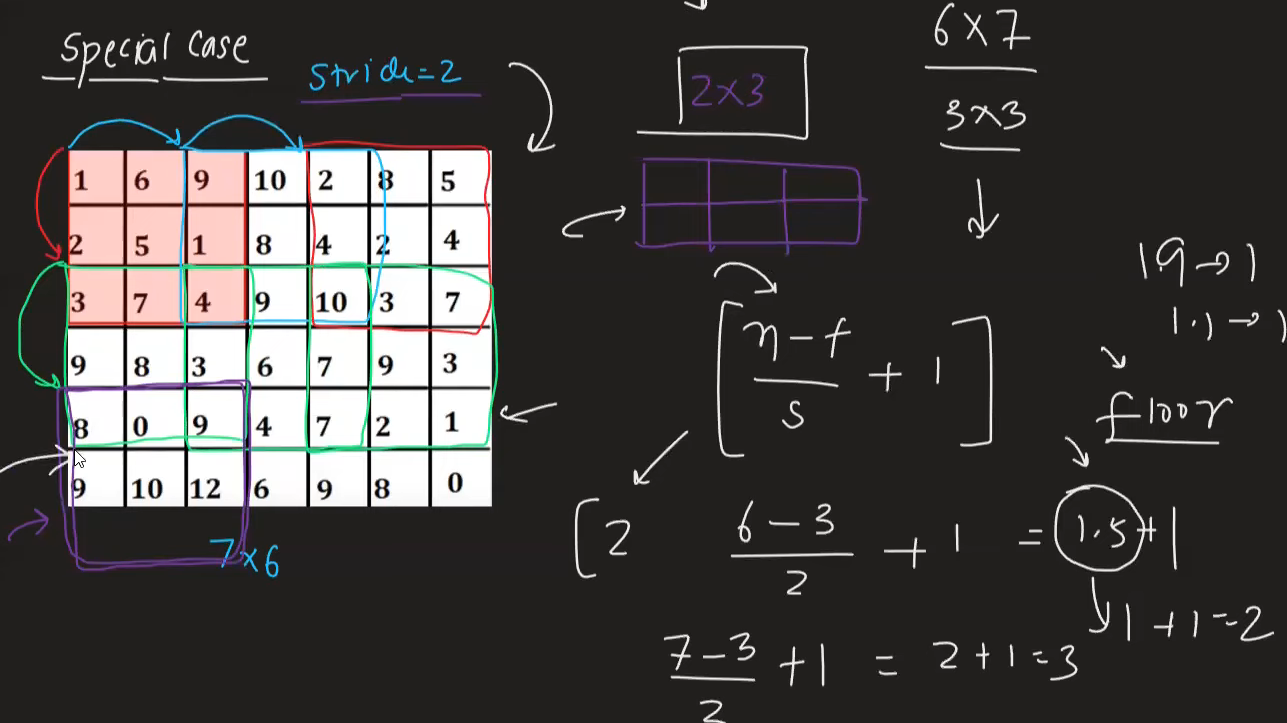



---

### 🧩 What’s Happening?

You have:
- A **7×6 input grid** (7 rows, 6 columns)
- A **3×3 filter** (kernel) that slides over the image
- **Stride = 2** → The filter moves **2 pixels at a time** (right and down)

The goal: Find how many positions the filter can cover → this gives the **output size**.

---

### 🔍 Step 1: Visual Example

Look at the red box (top-left):
```
[1 6 9]
[2 5 1]
[3 7 4]
```

Then move **2 steps right** → next green box:
```
[10 2 8]
[8  4 2]
[9 10 3]
```

Then move **2 steps down** → purple box:
```
[9 8 3]
[8 0 9]
[9 10 12]
```

So the filter jumps every 2 pixels — **stride = 2**.

👉 This means fewer output values, faster processing.

---

### ✅ Step 2: Output Size Formula

The formula for output size is:

> **Output size = ⌊(Input size - Filter size) / Stride⌋ + 1**

We write it like this:
```
O = floor((H - F) / S) + 1
```

Where:
- `H` = height of input
- `F` = filter height
- `S` = stride
- `⌊ ⌋` = floor (round down)

---

### 🔢 Apply to Your Case

Let’s use the **height** (7 rows):

- Input height `H = 7`
- Filter size `F = 3`
- Stride `S = 2`

Now plug in:
```
O = floor((7 - 3) / 2) + 1
  = floor(4 / 2) + 1
  = floor(2) + 1
  = 2 + 1 = 3
```

✅ So output height = **3**

Now width (6 columns):
```
O = floor((6 - 3) / 2) + 1
  = floor(3 / 2) + 1
  = floor(1.5) + 1
  = 1 + 1 = 2
```

✅ So output width = **2**

➡️ Final output size: **3 × 2**

---

### 📌 Why Is This Important?

- Without stride, we’d get more output values.
- With **stride=2**, we skip pixels → smaller output → faster computation.
- Useful in deep networks to reduce size quickly.

---

### ❗ Special Note: "Floor" Function

In math:
- `floor(1.5)` = `1` → always round **down**
- This is why `(6 - 3)/2 = 1.5` → becomes `1`, then `+1 = 2`

So even though 1.5 is close to 2, we **only count full positions**.

---

### ✅ Summary

| Input | Filter | Stride | Output Size |
|------|--------|--------|-------------|
| 7×6  | 3×3    | 2      | **3×2**     |

Formula:
> **Output = floor((H - F)/S) + 1**

This is used in CNNs to know how big the feature map will be after convolution.

---



**Why Strides are Required?**

1) **High-level features**  
   - When we use a large stride (e.g., stride = 2), the filter skips pixels and covers a larger area of the image in each step.  
   - This helps the network focus on **bigger patterns** like shapes or objects instead of small details.  
   - As we go deeper in a CNN, we want to detect **higher-level features** (like eyes, ears, or whole faces), not just edges.  
   - Strides help reduce the spatial size quickly so higher layers can see broader context.

2) **Computing → Efficiency**  
   - A smaller output means fewer calculations.  
   - With stride = 2, the number of positions the filter visits is **halved** compared to stride = 1.  
   - This reduces memory and computation time — very important for large images and deep networks.

---

### ✅ Summary

- **Strides let the model jump over pixels**, reducing output size.
- This helps capture **larger features** and makes training **faster and more efficient**.
- Without strides, every pixel would be processed one by one — too slow and too detailed for later layers.



We’ll keep it **coding-focused**, clear, and practical.

---

### 🔧 What is Stride in Code?

Stride controls **how many pixels the filter moves** each time it slides:
- `stride=1` → move 1 pixel
- `stride=2` → jump 2 pixels

You can set:
- Same stride in both directions: `stride=2` → means `(2, 2)`
- Or different: `stride=(1, 2)` → move 1 down, 2 right

---

### 🐍 1. **PyTorch: How to Set Stride**

```python
import torch
import torch.nn as nn

# Example: Create a convolution layer
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=(2, 1)  # ← You can change this!
    padding=0
)
```

#### ✅ Try These Stride Values:

| `stride=` | Meaning | Output Size Effect |
|----------|--------|---------------------|
| `(1, 1)` | Move 1 pixel down, 1 right | Slow, large output |
| `(2, 2)` | Move 2 down, 2 right | Fast, small output |
| `(2, 1)` | Move 2 down, 1 right | Tall & narrow output |
| `(1, 2)` | Move 1 down, 2 right | Wide & short output |

#### 💡 Example: See Output Shape

```python
# Input: batch=1, channel=1, height=7, width=6
x = torch.randn(1, 1, 7, 6)

# Apply conv with different strides
conv_v2h1 = nn.Conv2d(1, 1, 3, stride=(2, 1), padding=0)
out = conv_v2h1(x)

print(out.shape)  # Output: [1, 1, 3, 4]
# Why?
# H: floor((7-3)/2)+1 = 3
# W: floor((6-3)/1)+1 = 4
```

---

### 🧈 2. **TensorFlow/Keras: How to Set Stride**

```python
import tensorflow as tf

conv = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    strides=(2, 1),   # ← Change this!
    padding='valid'
)

# Example input: batch=1, H=7, W=6, C=1
x = tf.random.normal((1, 7, 6, 1))
out = conv(x)

print(out.shape)  # [1, 3, 4, 1] → same as above
```

#### ✅ All Possible Stride Combinations:

| Stride | Use Case |
|-------|---------|
| `(1, 1)` | Standard, keeps detail |
| `(2, 2)` | Common for downsampling (e.g., in ResNet) |
| `(1, 2)` | Good for wide images (e.g., text lines) → reduce width fast |
| `(2, 1)` | Good for tall images → reduce height fast |
| `(3, 1)` or `(1, 3)` | Aggressive downsampling in one direction |

---

### 📐 Formula (Always Works)

For any input size `(H, W)`, filter size `F`, padding `P`, stride `(S_h, S_w)`:

> **Output Height** = `floor((H - F + 2*P) / S_h) + 1`  
> **Output Width**  = `floor((W - F + 2*P) / S_w) + 1`

#### Example: `H=7, W=6, F=3, P=0, stride=(2,1)`
- H_out = `(7-3)/2 + 1 = 2 + 1 = 3`
- W_out = `(6-3)/1 + 1 = 3 + 1 = 4`
→ Output: `3×4`

---

### 🎯 When to Use Which Stride?

| Stride | Best For |
|-------|---------|
| `(1,1)` | Early layers, edge detection |
| `(2,2)` | Most CNNs — to downsample evenly |
| `(1,2)` | Audio spectrograms, text (wider than tall) |
| `(2,1)` | Satellite images, tall objects |
| `(3,3)` | Very large images — fast reduction |

---

### ✅ Summary

In code, you can set `stride` as:
- Single number: `stride=2` → applies to both directions
- Tuple: `stride=(2, 1)` → control vertical and horizontal separately

